<a href="https://colab.research.google.com/github/Castlebin/d2l-zh-pytorch-colab/blob/my_master/9_d2l-zh-pytorch-colab-reorg/07_%E7%8E%B0%E4%BB%A3%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/01_%E7%BB%8F%E5%85%B8CNN%E6%9E%B6%E6%9E%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 现代卷积神经网络架构

本notebook介绍CNN发展历程中的里程碑架构:
- AlexNet (2012): 深度学习的复兴
- VGG (2014): 更深的网络
- GoogLeNet/Inception (2014): 多尺度特征
- ResNet (2015): 残差连接突破深度

理解这些架构是深度学习的必修课!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import time

## 第一部分: AlexNet (2012)

### 1.1 历史背景

**深度学习的复兴**:
- **作者**: Alex Krizhevsky, Ilya Sutskever, Geoffrey Hinton
- **比赛**: ImageNet 2012 (ILSVRC)
- **成绩**: Top-5错误率15.3% (第二名26.2%)
- **意义**: 证明深度CNN超越传统方法

**为什么2012年之前没有成功?**
1. **数据不足**: 缺乏大规模标注数据
2. **计算能力**: 没有GPU加速
3. **技术缺失**: 没有ReLU、Dropout等技术

**AlexNet的突破**:
- 使用ImageNet (120万图像, 1000类)
- 2个NVIDIA GTX 580 GPU (3GB显存)
- ReLU激活函数
- Dropout正则化
- 数据增强

### 1.2 AlexNet架构

**网络结构** (8层):
```
输入: 224×224×3
  ↓
Conv1: 96个11×11核, stride=4  → 54×54×96
MaxPool: 3×3, stride=2         → 26×26×96
  ↓
Conv2: 256个5×5核             → 26×26×256
MaxPool: 3×3, stride=2         → 12×12×256
  ↓
Conv3: 384个3×3核             → 12×12×384
Conv4: 384个3×3核             → 12×12×384
Conv5: 256个3×3核             → 12×12×256
MaxPool: 3×3, stride=2         → 5×5×256
  ↓
Flatten                        → 6400
FC1: 4096 + Dropout
FC2: 4096 + Dropout
FC3: 1000 (分类)
```

**关键创新**:
1. **ReLU**: 替代Sigmoid/Tanh, 缓解梯度消失
2. **Dropout**: 全连接层使用50% dropout
3. **重叠池化**: stride < kernel_size
4. **数据增强**: 随机裁剪、翻转、颜色抖动
5. **局部响应归一化(LRN)**: 后来被BatchNorm替代

### 1.3 实现AlexNet

In [ ]:
class AlexNet(nn.Module):
    """AlexNet架构 (简化版,适配Fashion-MNIST)"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 特征提取器
        self.features = nn.Sequential(
            # Conv1: 1→96, 11×11, stride=4
            nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2: 96→256, 5×5
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3-5: 3×3卷积
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # 分类器
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 5 * 5, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# 创建模型
alexnet = AlexNet()
print(alexnet)

# 参数量
total_params = sum(p.numel() for p in alexnet.parameters())
print(f"\n总参数量: {total_params:,}")

### 1.4 验证形状

In [ ]:
# 输入: 224×224 (ImageNet标准)
X = torch.randn(1, 1, 224, 224)

print("AlexNet各层输出形状:")
print("-" * 60)

# 特征提取层
for i, layer in enumerate(alexnet.features):
    X = layer(X)
    print(f"Layer {i} {layer.__class__.__name__:12s}: {list(X.shape)}")

# 展平
X = X.view(X.size(0), -1)
print(f"\nFlatten: {list(X.shape)}")

# 分类器
for i, layer in enumerate(alexnet.classifier):
    X = layer(X)
    print(f"Classifier {i} {layer.__class__.__name__:12s}: {list(X.shape)}")

---

## 第二部分: VGG (2014)

### 2.1 VGG的设计哲学

**核心思想**: **更深 + 更简单**

- 作者: Karen Simonyan & Andrew Zisserman (牛津大学)
- 全称: Visual Geometry Group

**设计原则**:
1. **小卷积核**: 全部使用3×3卷积
2. **统一结构**: 重复使用相同的VGG块
3. **逐层加深**: 16-19层
4. **通道翻倍**: 64→128→256→512

**为什么用3×3卷积?**
- 2个3×3卷积 = 1个5×5卷积的感受野
- 3个3×3卷积 = 1个7×7卷积的感受野
- 但参数更少: $3 \times (3^2 C^2) < 7^2 C^2$
- 更多非线性(更多ReLU层)

### 2.2 VGG架构

**VGG块结构**:
```
Conv 3×3 + ReLU
Conv 3×3 + ReLU  (可重复)
...
MaxPool 2×2, stride=2
```

**VGG-16配置**:
```
输入: 224×224×3
Block1: 2×Conv(64)  + Pool  → 112×112×64
Block2: 2×Conv(128) + Pool  → 56×56×128
Block3: 3×Conv(256) + Pool  → 28×28×256
Block4: 3×Conv(512) + Pool  → 14×14×512
Block5: 3×Conv(512) + Pool  → 7×7×512
FC: 4096 → 4096 → 1000
```

**VGG变体**:
- VGG-11: 8个卷积层 + 3个全连接层
- VGG-13: 10个卷积层
- VGG-16: 13个卷积层 ✨ (最常用)
- VGG-19: 16个卷积层

### 2.3 实现VGG

In [ ]:
def vgg_block(num_convs, in_channels, out_channels):
    """VGG块: num_convs个3×3卷积 + 1个MaxPool"""
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, padding=1))
        layers.append(nn.ReLU(inplace=True))
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

class VGG(nn.Module):
    """VGG网络"""
    def __init__(self, conv_arch, num_classes=10):
        super().__init__()

        # 卷积层部分
        conv_blks = []
        in_channels = 1
        for (num_convs, out_channels) in conv_arch:
            conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
            in_channels = out_channels

        self.features = nn.Sequential(*conv_blks)

        # 全连接层部分
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# VGG-11配置 (简化版)
# (num_convs, out_channels)
vgg11_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

vgg11 = VGG(vgg11_arch)
print(vgg11)

total_params = sum(p.numel() for p in vgg11.parameters())
print(f"\nVGG-11 参数量: {total_params:,}")

### 2.4 VGG的优缺点

**优点** ✅:
- 结构简单统一,易于实现
- 3×3小卷积核,参数效率高
- 性能强大,易于迁移学习

**缺点** ❌:
- 参数量巨大(VGG-16: 138M)
- 训练和推理慢
- 内存消耗大

---

## 第三部分: GoogLeNet/Inception (2014)

### 3.1 Inception的动机

**核心问题**: 什么大小的卷积核最好?
- 小核(1×1, 3×3): 计算快,感受野小
- 大核(5×5, 7×7): 感受野大,计算慢

**Inception的答案**: **全都要!**

同时使用多种尺寸的卷积核,让网络自己学习哪个重要。

### 3.2 Inception块

**结构** (4条并行路径):
```
输入
  ├─→ 1×1 Conv ─────────────────→┐
  ├─→ 1×1 Conv → 3×3 Conv ───────→├─→ Concat → 输出
  ├─→ 1×1 Conv → 5×5 Conv ───────→┤
  └─→ 3×3 MaxPool → 1×1 Conv ────→┘
```

**关键设计**:
1. **多尺度**: 1×1, 3×3, 5×5卷积并行
2. **1×1卷积降维**: 减少计算量
3. **最后concat**: 在通道维度拼接

**为什么有效?**
- 不同尺度特征互补
- 1×1卷积大幅降低参数量
- 网络宽度和深度同时增加

### 3.3 实现Inception

In [ ]:
class Inception(nn.Module):
    """Inception块"""
    def __init__(self, in_channels, c1, c2, c3, c4):
        """
        c1: 路径1的输出通道(1×1卷积)
        c2: 路径2的输出通道(1×1→3×3)
        c3: 路径3的输出通道(1×1→5×5)
        c4: 路径4的输出通道(3×3pool→1×1)
        """
        super().__init__()

        # 路径1: 1×1卷积
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)

        # 路径2: 1×1卷积 → 3×3卷积
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)

        # 路径3: 1×1卷积 → 5×5卷积
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)

        # 路径4: 3×3最大池化 → 1×1卷积
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度concat
        return torch.cat((p1, p2, p3, p4), dim=1)

# 测试Inception块
inception = Inception(192, 64, (96, 128), (16, 32), 32)
X = torch.randn(1, 192, 28, 28)
output = inception(X)
print(f"输入: {X.shape}")
print(f"输出: {output.shape}")
print(f"输出通道数: 64 + 128 + 32 + 32 = {64+128+32+32}")

### 3.4 GoogLeNet架构

完整的GoogLeNet包含9个Inception块,这里只展示简化版本。

**特点**:
- 22层深度
- 参数量仅5M (远小于AlexNet的60M)
- 使用全局平均池化替代全连接层
- 辅助分类器(训练时使用,推理时移除)

---

## 第四部分: ResNet (2015)

### 4.1 深度网络的困境

**理论**: 更深的网络应该至少不比浅网络差
- 深网络可以学习恒等映射
- 额外的层可以什么都不学

**现实**: 更深的网络训练困难
- 梯度消失/爆炸
- 退化问题: 训练误差反而上升!

**ResNet的突破**: **残差学习**

### 4.2 残差块

**核心思想**: 学习残差而不是直接学习目标映射

**传统网络**:
$$H(x) = F(x)$$

**残差网络**:
$$H(x) = F(x) + x$$

其中 $F(x)$ 是残差映射。

**为什么有效?**
1. **恒等映射易学**: $F(x) = 0$ 即可实现恒等
2. **梯度畅通**: 跳跃连接提供梯度高速公路
3. **集成效果**: 相当于多个浅网络的集成

**残差块结构**:
```
输入 x
  ├─→ Conv 3×3 → BN → ReLU → Conv 3×3 → BN ─→ (+) → ReLU → 输出
  └────────────────────────────────────────→ ┘
              (跳跃连接 / shortcut)
```

### 4.3 实现ResNet

In [ ]:
class Residual(nn.Module):
    """残差块"""
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        # 主路径
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, padding=1, stride=stride)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, padding=1)

        # 跳跃连接(如果通道数或尺寸变化)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels,
                                   kernel_size=1, stride=stride)
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        # 主路径
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        # 跳跃连接
        if self.conv3:
            x = self.conv3(x)

        # 相加后激活
        return F.relu(y + x)

# 测试残差块
residual = Residual(3, 3)
X = torch.randn(1, 3, 6, 6)
print(f"输入输出同形状: {X.shape} → {residual(X).shape}")

# 改变通道数和尺寸
residual2 = Residual(3, 6, use_1x1conv=True, stride=2)
print(f"改变通道和尺寸: {X.shape} → {residual2(X).shape}")

In [ ]:
def resnet_block(in_channels, out_channels, num_residuals, first_block=False):
    """ResNet块: 包含多个残差块"""
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            # 第一个残差块可能改变通道数和尺寸
            blk.append(Residual(in_channels, out_channels,
                               use_1x1conv=True, stride=2))
        else:
            blk.append(Residual(out_channels, out_channels))
    return nn.Sequential(*blk)

class ResNet(nn.Module):
    """ResNet-18架构"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 初始层
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # ResNet块
        self.b2 = resnet_block(64, 64, 2, first_block=True)
        self.b3 = resnet_block(64, 128, 2)
        self.b4 = resnet_block(128, 256, 2)
        self.b5 = resnet_block(256, 512, 2)

        # 全局平均池化 + 分类
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.classifier(x)
        return x

resnet18 = ResNet()
print(resnet18)

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"\nResNet-18 参数量: {total_params:,}")

### 4.4 ResNet的变体

| 模型 | 层数 | 参数量 | Top-5错误率 |
|------|------|--------|-------------|
| ResNet-18 | 18 | 11.7M | ~10% |
| ResNet-34 | 34 | 21.8M | ~7.5% |
| ResNet-50 | 50 | 25.6M | ~6.7% |
| ResNet-101 | 101 | 44.5M | ~6.2% |
| ResNet-152 | 152 | 60.2M | ~5.7% |

**ResNet-50/101/152** 使用**瓶颈残差块**:
```
1×1 Conv (降维) → 3×3 Conv → 1×1 Conv (升维)
```
减少计算量的同时保持性能。

---

## 第五部分: 架构对比

### 5.1 性能对比

In [ ]:
import pandas as pd

# 模型对比数据
data = {
    '模型': ['LeNet-5', 'AlexNet', 'VGG-16', 'GoogLeNet', 'ResNet-50'],
    '年份': [1998, 2012, 2014, 2014, 2015],
    '层数': [7, 8, 16, 22, 50],
    '参数量(M)': [0.06, 60, 138, 5, 25.6],
    'Top-5错误率(%)': ['-', 15.3, 7.3, 6.7, 5.3],
    '核心创新': ['卷积+池化', 'ReLU+Dropout+GPU', '3×3小核', 'Inception块', '残差连接']
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 层数趋势
axes[0].plot(df['年份'], df['层数'], marker='o', linewidth=2, markersize=10)
axes[0].set_xlabel('年份', fontsize=12)
axes[0].set_ylabel('层数', fontsize=12)
axes[0].set_title('CNN深度演进', fontsize=14)
axes[0].grid(True, alpha=0.3)
for i, model in enumerate(df['模型']):
    axes[0].text(df['年份'][i], df['层数'][i] + 2, model,
                ha='center', fontsize=10)

# 参数量对比
axes[1].bar(df['模型'], df['参数量(M)'], color='steelblue', alpha=0.7)
axes[1].set_ylabel('参数量 (百万)', fontsize=12)
axes[1].set_title('参数量对比', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Top-5错误率(排除LeNet)
df_imagenet = df[df['模型'] != 'LeNet-5'].copy()
df_imagenet['Top-5错误率(%)'] = pd.to_numeric(df_imagenet['Top-5错误率(%)'])
axes[2].plot(df_imagenet['模型'], df_imagenet['Top-5错误率(%)'],
            marker='s', linewidth=2, markersize=10, color='coral')
axes[2].set_ylabel('Top-5错误率 (%)', fontsize=12)
axes[2].set_title('ImageNet性能提升', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n观察:")
print("1. 网络深度: 7层 → 50层")
print("2. 错误率: 15.3% → 5.3%")
print("3. 参数量: 不是越大越好(GoogLeNet只有5M)")

### 5.2 设计哲学对比

| 模型 | 核心思想 | 主要技术 | 适用场景 |
|------|----------|----------|----------|
| **AlexNet** | 更深+现代技术 | ReLU, Dropout, 数据增强 | 开创性,已过时 |
| **VGG** | 小核+规整 | 统一3×3卷积,重复块 | 迁移学习,特征提取 |
| **GoogLeNet** | 宽度+深度 | Inception, 1×1降维 | 参数受限场景 |
| **ResNet** | 极深网络 | 残差连接, BatchNorm | 通用,SOTA基线 |

**选择建议**:
- **学习**: VGG (结构简单)
- **迁移学习**: ResNet (预训练模型多)
- **移动端**: MobileNet, EfficientNet (后续发展)
- **研究**: ResNet (改进空间大)

---

## 小结

### CNN发展历程

1. **LeNet (1998)**: 奠定基础
   - 卷积+池化+全连接
   - 在MNIST上成功

2. **AlexNet (2012)**: 深度学习复兴 🔥
   - ImageNet突破
   - ReLU + Dropout + GPU
   - 开启深度学习热潮

3. **VGG (2014)**: 简洁美学
   - 统一3×3卷积
   - 模块化设计
   - 易于理解和实现

4. **GoogLeNet (2014)**: 效率至上
   - Inception多尺度
   - 1×1降维
   - 参数少性能好

5. **ResNet (2015)**: 深度突破 🚀
   - 残差连接
   - 152层网络可训练
   - 现代CNN的标准

### 核心技术演进

**激活函数**:
- Sigmoid/Tanh → **ReLU** → Leaky ReLU → GELU

**正则化**:
- L2正则 → **Dropout** → **BatchNorm** → LayerNorm

**优化技术**:
- SGD → **Adam** → AdamW → LAMB

**架构设计**:
- 堆叠层 → **重复块** → **残差连接** → Attention

### 关键洞察

1. **深度很重要**: 但需要残差连接等技术支持
2. **小卷积核**: 多个3×3优于单个大核
3. **1×1卷积**: 降维、升维、跨通道交互
4. **BatchNorm**: 加速训练、提高泛化
5. **残差连接**: 使极深网络可训练
6. **数据增强**: 和网络架构同样重要

### 未来方向

- **AutoML**: NAS自动搜索架构
- **Transformer**: 注意力机制(ViT)
- **高效网络**: MobileNet, EfficientNet
- **神经架构搜索**: 自动化设计

## 练习

1. **实现对比**: 在Fashion-MNIST上训练VGG和ResNet,对比性能
2. **感受野计算**: 计算VGG-16和ResNet-18的感受野
3. **参数分析**: 分析为什么GoogLeNet参数少但性能好
4. **残差连接**: 实验移除残差连接,观察训练困难
5. **可视化**: 可视化不同层学到的特征
6. **迁移学习**: 使用预训练ResNet进行迁移学习

In [1]:
!pip install torchinfo dl_d2l matplotlib_cn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dl_d2l: filename=dl_d2l-1.0.28-py3-none-any.whl size=5338765 sha256=9853ac6dbd2c7ceb5f3fa0898d3701d2d589c27420ed6c8b8f831b3f80fef724
  Stored in directory: /root/.cache/pip/wheels/97/f5/31/1ec94020350640b5c4b4a3db1b1c33131be308e709a8adf5b6
  Created wheel for matplotlib_cn: filename=matplotlib_cn-1.0.6-py3-none-any.whl size=5294814 sha256=64e4acd855ecfc7f4d4ccac97c85fa8849bc27445ac830033e8718cd9710f1f6
  Stored in directory: /root/.cache/pip/wheels/94/0e/0a/24533496ebe74869272175719e64e798bc1f5452e82894fbb2
Successfully built dl_d2l matplotlib_cn


loss 0.329, train acc 0.879, test acc 0.883
1093.8 examples/sec on cuda


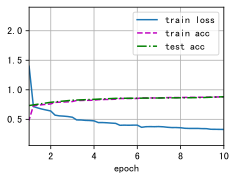

In [ ]:
# @title 7.1. 深度卷积神经网络（AlexNet）

# %% 7.1.2. AlexNet
# AlexNet
import os
import torch
import torchinfo
from dl_d2l import d2l_torch as d2l
from dl_d2l.util import colab_util
from dl_d2l.util import device_util
from matplotlib_cn import matplotlib_util
from torch import nn

matplotlib_util.enable_chinese()

from matplotlib import pyplot as plt

net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))

# %% 观察一下模型
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

# %% 使用 torchinfo 查看模型信息
torchinfo.summary(net)

# %% 7.1.3. 读取数据集
base_data_dir = colab_util.get_base_data_dir()
print(f'base data dir: {base_data_dir}')

datasets_dir = os.path.join(base_data_dir, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'datasets dir: {datasets_dir}')

# 获取可用的设备
device = device_util.get_available_device()

# %% 加载数据集
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size, resize=224, root_dir=datasets_dir)

# %% 7.1.4. 训练 AlexNet
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

plt.show()


loss 0.183, train acc 0.933, test acc 0.918
755.1 examples/sec on cuda


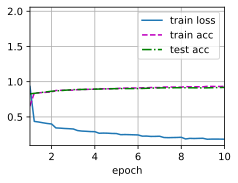

In [2]:
# @title 7.2. 使用块的网络（VGG）

# %% 7.2.1. VGG 块
import torch
from torch import nn


def vgg_block(num_convs, in_channels, out_channels):
    """
    :param num_convs: 卷积层的数量
    :param in_channels: 输入通道的数量
    :param out_channels: 输出通道的数量
    :return: VGG block
    """
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels

    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)


# %% 7.2.2. VGG网络
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))


def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全连接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10))


net = vgg(conv_arch)

# %% 构建一个高度和宽度为 224 的单通道数据样本，以观察每个层输出的形状
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__, 'output shape:\t', X.shape)

# %% 使用 torchinfo 观察模型
import torchinfo

torchinfo.summary(net)

# %% 7.2.3. 训练模型
'''由于VGG-11比AlexNet计算量更大，因此我们构建了一个通道数较少的网络，足够用于训练Fashion-MNIST数据集。'''
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

torchinfo.summary(net)

# %% 训练
from dl_d2l import d2l_torch as d2l
from dl_d2l.util import colab_util, device_util
import os
from matplotlib import pyplot as plt

base_data_dir = colab_util.get_base_data_dir()
print(f'base data dir: {base_data_dir}')

datasets_dir = os.path.join(base_data_dir, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'datasets dir: {datasets_dir}')

# 获取可用的设备
device = device_util.get_available_device()

# 训练模型
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

plt.show()


In [3]:
# 7.3. 网络中的网络（NiN）

loss 0.436, train acc 0.837, test acc 0.824
861.7 examples/sec on cuda:0


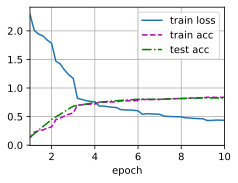

In [4]:
import torch
from torch import nn
from dl_d2l import d2l_torch as d2l


def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())



net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())


X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)


# %% 使用 torchinfo 查看模型信息
torchinfo.summary(net)


from dl_d2l import d2l_torch as d2l
from dl_d2l.util import colab_util, device_util
import os
from matplotlib import pyplot as plt

base_data_dir = colab_util.get_base_data_dir()
print(f'base data dir: {base_data_dir}')

datasets_dir = os.path.join(base_data_dir, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'datasets dir: {datasets_dir}')

# 获取可用的设备
device = device_util.get_available_device()

lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())



# 7.4. 含并行连结的网络（GoogLeNet）

loss 0.249, train acc 0.905, test acc 0.895
1260.1 examples/sec on cuda:0


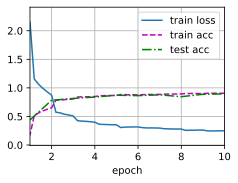

In [5]:
import torch
from torch import nn
from torch.nn import functional as F
from dl_d2l import d2l_torch as d2l


class Inception(nn.Module):
    # c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)


b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))


b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                   nn.ReLU(),
                   nn.Conv2d(64, 192, kernel_size=3, padding=1),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))


b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))


b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))


b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))


X = torch.rand(size=(1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)


# %% 使用 torchinfo 查看模型信息
torchinfo.summary(net)



# 和以前一样，我们使用Fashion-MNIST数据集来训练我们的模型。在训练之前，我们将图片转换为 96 * 96 分辨率。
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

plt.show()


# 7.5. 批量规范化

loss 0.268, train acc 0.900, test acc 0.675
10500.9 examples/sec on cuda:0


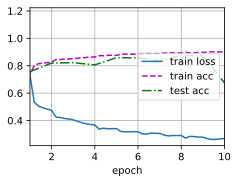

In [8]:
import torch
from torch import nn
from dl_d2l import d2l_torch as d2l

def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data



class BatchNorm(nn.Module):
    # num_features：完全连接层的输出数量或卷积层的输出通道数。
    # num_dims：2表示完全连接层，4表示卷积层
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # 参与求梯度和迭代的拉伸和偏移参数，分别初始化成1和0
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # 如果X不在内存上，将moving_mean和moving_var
        # 复制到X所在显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y



net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16*4*4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))


lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

plt.show()


# 7.6. 残差网络（ResNet）

In [9]:
import torch
from torch import nn
from torch.nn import functional as F


class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape




torch.Size([4, 3, 6, 6])

In [10]:
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

In [11]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))



In [12]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk



In [13]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [14]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))


In [15]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)



Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


In [16]:
torchinfo.summary(net)


Layer (type:depth-idx)                   Param #
Sequential                               --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       3,200
│    └─BatchNorm2d: 2-2                  128
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─Residual: 2-5                     --
│    │    └─Conv2d: 3-1                  36,928
│    │    └─Conv2d: 3-2                  36,928
│    │    └─BatchNorm2d: 3-3             128
│    │    └─BatchNorm2d: 3-4             128
│    └─Residual: 2-6                     --
│    │    └─Conv2d: 3-5                  36,928
│    │    └─Conv2d: 3-6                  36,928
│    │    └─BatchNorm2d: 3-7             128
│    │    └─BatchNorm2d: 3-8             128
├─Sequential: 1-3                        --
│    └─Residual: 2-7                     --
│    │    └─Conv2d: 3-9                  73,856
│    │    └─Conv2d: 3-10                 14

loss 0.014, train acc 0.996, test acc 0.917
1627.5 examples/sec on cuda:0


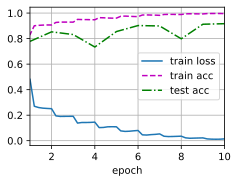

In [17]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())


# 7.7. 稠密连接网络（DenseNet）

In [18]:
import torch
from torch import nn


def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

In [19]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

In [20]:
blk = DenseBlock(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

In [21]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

In [22]:
blk = transition_block(23, 10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

In [23]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [24]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

In [25]:
net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

loss 0.142, train acc 0.949, test acc 0.796
1889.1 examples/sec on cuda:0


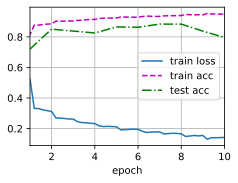

In [26]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96, root_dir=datasets_dir)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

plt.show()